In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
diabetes_df = pd.read_csv('diabetes.csv')

In [3]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
diabetes_df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: >

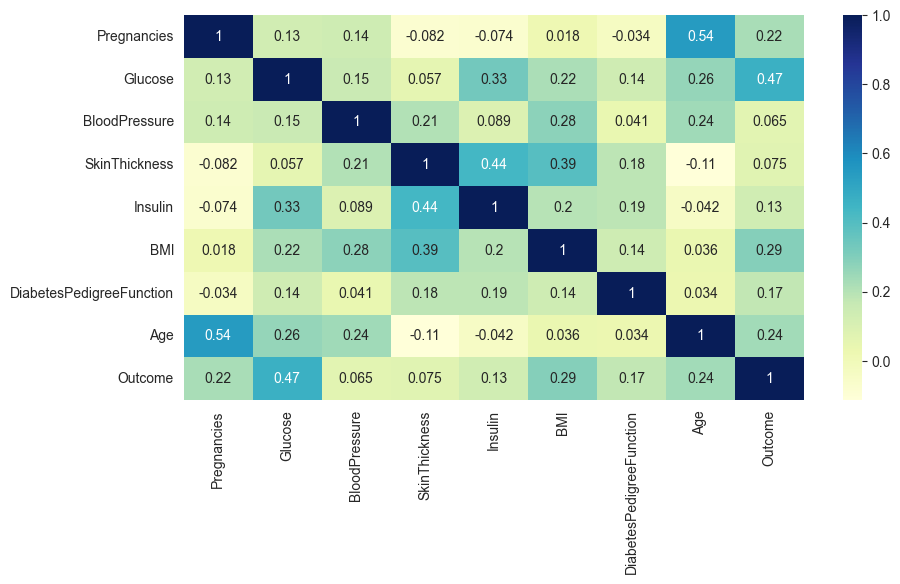

In [4]:
plt.figure(figsize=(10,5))
sns.heatmap(diabetes_df.corr(), annot=True, cmap='YlGnBu')

disini kita akan memisahkan data untuk autogluon, random state 0 tidak ada bedanya dengan random state 42

In [4]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(diabetes_df, test_size = 0.2, random_state = 0)

In [5]:
from autogluon.tabular import TabularPredictor

C:\Users\muhammadraiyansani\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


disini digunakan path agar nantinya model bisa langsung di load

In [6]:
predictor=TabularPredictor.load('deteksi_diabetes/best_200_1')

This could mean that the predictor was fit in a version `<=0.5.2`.


jika sebelumnya sudah membuat model, kita tidak perlu membuat model ulang, cukup load dengan path nya saja

In [8]:
predictor= TabularPredictor(path='deteksi_diabetes/best_200_1',label='Outcome',eval_metric='accuracy',problem_type='binary').fit(df_train,presets='best_quality',time_limit=200)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.7
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          22
Memory Avail:       3.96 GB / 15.61 GB (25.4%)
Disk Space Avail:   262.09 GB / 475.92 GB (55.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is use

(_ray_fit pid=13632) [1000]	valid_set's binary_error: 0.191176


(_dystack pid=11172) 	0.8367	 = Validation score   (accuracy)
(_dystack pid=11172) 	1.04s	 = Training   runtime
(_dystack pid=11172) 	0.01s	 = Validation runtime
(_dystack pid=11172) Fitting model: WeightedEnsemble_L3 ... Training model for up to 40.52s of the -0.18s of remaining time.
(_dystack pid=11172) 	Ensemble Weights: {'LightGBM_BAG_L2': 1.0}
(_dystack pid=11172) 	0.8367	 = Validation score   (accuracy)
(_dystack pid=11172) 	0.03s	 = Training   runtime
(_dystack pid=11172) 	0.0s	 = Validation runtime
(_dystack pid=11172) AutoGluon training complete, total runtime = 40.79s ... Best model: WeightedEnsemble_L3 | Estimated inference throughput: 2874.7 rows/s (69 batch size)
(_dystack pid=11172) Disabling decision threshold calibration for metric `accuracy` due to having fewer than 10000 rows of validation data for calibration, to avoid overfitting (545 rows).
(_dystack pid=11172) 	`accuracy` is generally not improved through threshold calibration. Force calibration via specifying `c

In [8]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.807818,accuracy,0.102561,14.362758,0.000000,0.056295,2,True,22
1,NeuralNetFastAI_r191_BAG_L1,0.798046,accuracy,0.075651,9.321791,0.075651,9.321791,1,True,15
2,NeuralNetFastAI_BAG_L1,0.793160,accuracy,0.085412,7.582611,0.085412,7.582611,1,True,8
3,NeuralNetTorch_r22_BAG_L1,0.789902,accuracy,0.044983,11.706223,0.044983,11.706223,1,True,18
4,CatBoost_r137_BAG_L1,0.788274,accuracy,0.022313,3.260703,0.022313,3.260703,1,True,21
5,LightGBMXT_BAG_L1,0.786645,accuracy,0.002002,0.994509,0.002002,0.994509,1,True,1
6,LightGBM_BAG_L1,0.785016,accuracy,0.008525,2.074584,0.008525,2.074584,1,True,2
7,CatBoost_r177_BAG_L1,0.783388,accuracy,0.004228,6.983735,0.004228,6.983735,1,True,12
8,XGBoost_BAG_L1,0.783388,accuracy,0.004596,1.723969,0.004596,1.723969,1,True,9
9,CatBoost_BAG_L1,0.783388,accuracy,0.016046,3.045813,0.016046,3.045813,1,True,5


In [9]:
predictor.evaluate(df_test)

{'accuracy': 0.8116883116883117,
 'balanced_accuracy': np.float64(0.77500497116723),
 'mcc': 0.553376311645231,
 'roc_auc': np.float64(0.8614038576257705),
 'f1': 0.6881720430107527,
 'precision': 0.6956521739130435,
 'recall': 0.6808510638297872}

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'WeightedEnsemble_L2'),
  Text(1, 0, 'NeuralNetFastAI_r191_BAG_L1'),
  Text(2, 0, 'NeuralNetFastAI_BAG_L1'),
  Text(3, 0, 'NeuralNetTorch_r22_BAG_L1'),
  Text(4, 0, 'CatBoost_r137_BAG_L1'),
  Text(5, 0, 'LightGBMXT_BAG_L1'),
  Text(6, 0, 'LightGBM_BAG_L1'),
  Text(7, 0, 'CatBoost_r177_BAG_L1'),
  Text(8, 0, 'XGBoost_BAG_L1'),
  Text(9, 0, 'CatBoost_BAG_L1'),
  Text(10, 0, 'CatBoost_r9_BAG_L1'),
  Text(11, 0, 'LightGBM_r96_BAG_L1'),
  Text(12, 0, 'NeuralNetTorch_r79_BAG_L1'),
  Text(13, 0, 'XGBoost_r33_BAG_L1'),
  Text(14, 0, 'LightGBM_r131_BAG_L1'),
  Text(15, 0, 'NeuralNetTorch_BAG_L1'),
  Text(16, 0, 'LightGBMLarge_BAG_L1'),
  Text(17, 0, 'RandomForestEntr_BAG_L1'),
  Text(18, 0, 'ExtraTrees_r42_BAG_L1'),
  Text(19, 0, 'RandomForestGini_BAG_L1'),
  Text(20, 0, 'ExtraTreesGini_BAG_L1'),
  Text(21, 0, 'ExtraTreesEntr_BAG_L1')])

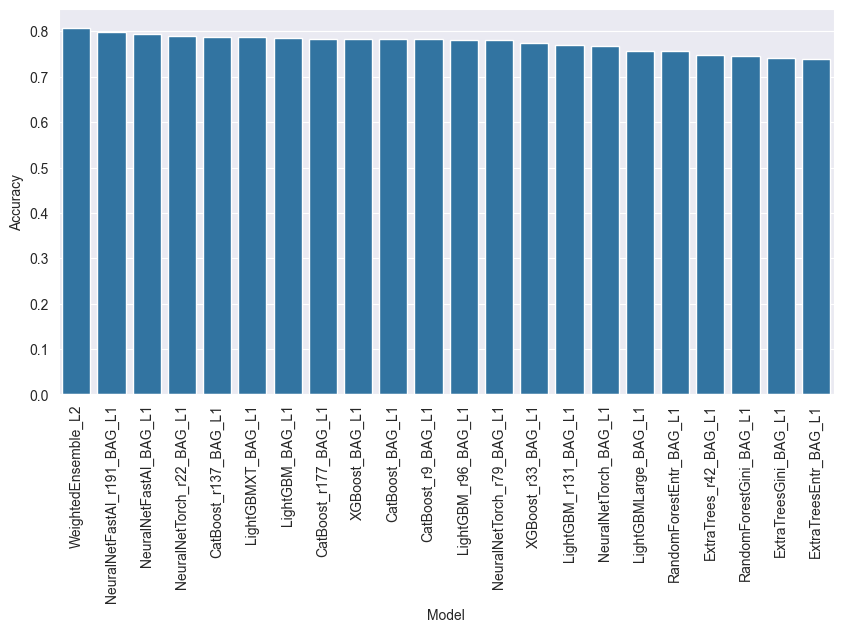

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(x='model',y='score_val',data=predictor.leaderboard())
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=90)

In [11]:
from sklearn.metrics import confusion_matrix

<Axes: >

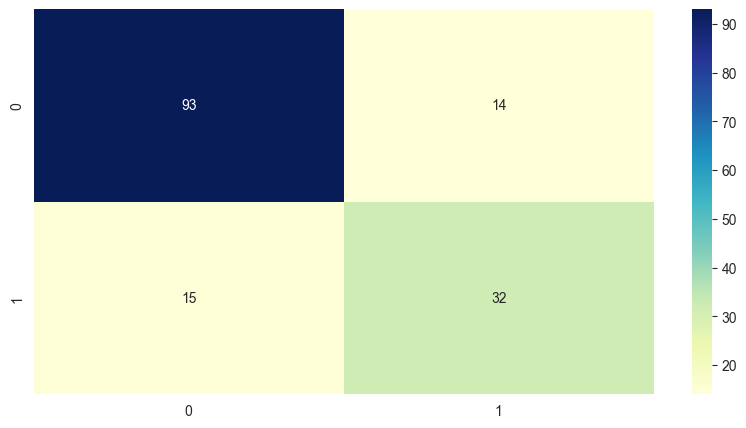

In [12]:
y_true=df_test['Outcome']
con=confusion_matrix(y_true,predictor.predict(df_test))
plt.figure(figsize=(10,5))
sns.heatmap(con, annot=True, cmap='YlGnBu')

In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_true,predictor.predict(df_test)))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       107
           1       0.70      0.68      0.69        47

    accuracy                           0.81       154
   macro avg       0.78      0.78      0.78       154
weighted avg       0.81      0.81      0.81       154

